#1. Install DEAP library

In [2]:
!pip install deap # install the package

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 4.2 MB/s eta 0:00:00


#2. Import Libraries and Define the Fitness Function

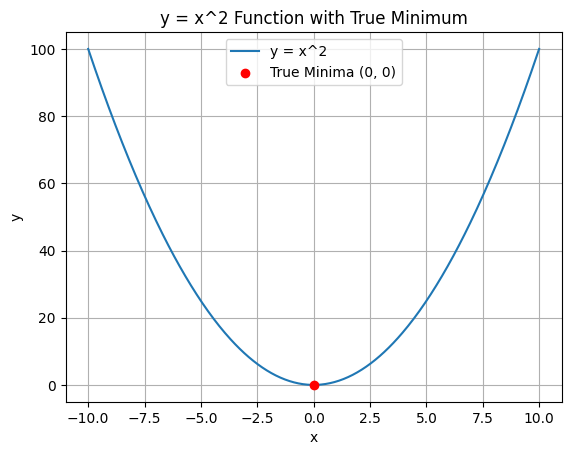

In [10]:
import random
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms

# Define the function y = x^2
def function_to_minimize(x):
    return x**2

# True minimum point (Given)
true_min_x = 0
true_min_y = 0

# Plot the function and true minimum
x_vals = np.linspace(-10, 10, 400)
y_vals = function_to_minimize(x_vals)
plt.plot(x_vals, y_vals, label="y = x^2")
plt.scatter(true_min_x, true_min_y, color='red', label="True Minima (0, 0)", zorder=5)
plt.title("y = x^2 Function with True Minimum")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


#3. Set Up GA for Minimizing y = x²

In [5]:
# Define the individual and fitness function for GA
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

# Define how to initialize individuals (random values between -10 and 10)
def individual_init():
    return [random.uniform(-10, 10)]

toolbox = base.Toolbox()
toolbox.register("individual", tools.initIterate, creator.Individual, individual_init)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Define the evaluation function y = x^2
def eval_function(individual):
    x = individual[0]
    return (x**2,)

toolbox.register("evaluate", eval_function)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)


/usr/local/lib/python3.10/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.10/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


#4. Run the GA and Get Results

In [6]:
# Set up the GA process
population = toolbox.population(n=100)
result, log = algorithms.eaSimple(population, toolbox, cxpb=0.7, mutpb=0.2, ngen=40, verbose=False)

# Get the best individual found by GA
best_individual = tools.selBest(population, k=1)[0]
best_fitness = eval_function(best_individual)

print(f'Best individual found by GA: {best_individual[0]}, Fitness: {best_fitness[0]}')


Best individual found by GA: -5.12075113081162e-18, Fitness: 2.6222092143708486e-35


#5. Plot the GA Result

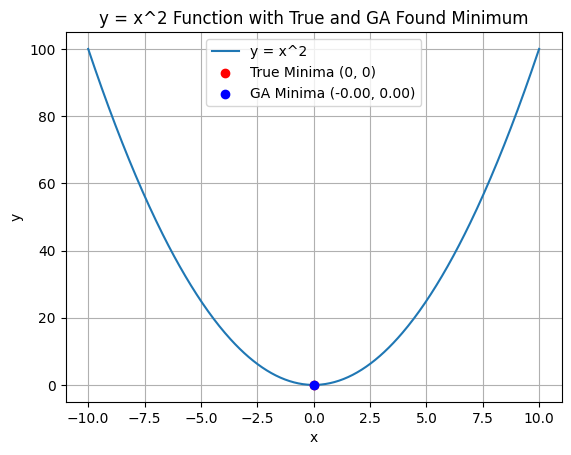

True Minima: (0, 0)
GA Minima: (-0.00, 0.00)


In [9]:
# Plot the function again
plt.plot(x_vals, y_vals, label="y = x^2")

# Plot true minimum
plt.scatter(true_min_x, true_min_y, color='red', label="True Minima (0, 0)", zorder=5)

# Plot GA result
ga_min_x = best_individual[0]
ga_min_y = best_fitness[0]
plt.scatter(ga_min_x, ga_min_y, color='blue', label=f"GA Minima ({ga_min_x:.2f}, {ga_min_y:.2f})", zorder=5)

plt.title("y = x^2 Function with True and GA Found Minimum")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

print(f"True Minima: (0, 0)")
print(f"GA Minima: ({ga_min_x:.2f}, {ga_min_y:.2f})")


# Now, try to evaluate this function

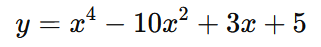

# Given: True value of global minima (for checking GA results)
true_min_x = -2.31  
true_min_y = -26.82


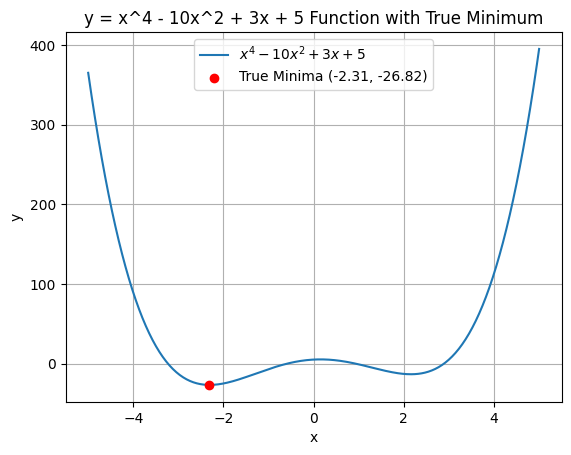

In [22]:
# Define the function y = x^4 - 10x^2 + 3x + 5
def function_to_minimize(x):
    return x**4 - 10*x**2 + 3*x + 5

# True minimum point (Given, for checking GA results)
true_min_x = -2.31
true_min_y = -26.82

# Plot the function and true minimum
x_vals = np.linspace(-5, 5, 400)
y_vals = function_to_minimize(x_vals)
plt.plot(x_vals, y_vals, label=r"$x^4 - 10x^2 + 3x + 5$")
plt.scatter(true_min_x, true_min_y, color='red', label=f"True Minima ({true_min_x:.2f}, {true_min_y:.2f})", zorder=5)
plt.title("y = x^4 - 10x^2 + 3x + 5 Function with True Minimum")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


In [19]:
# Define the individual and fitness function for GA
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

# Define how to initialize individuals (random values between -5 and 5)
def individual_init():
    return [random.uniform(-5, 5)]

toolbox = base.Toolbox()
toolbox.register("individual", tools.initIterate, creator.Individual, individual_init)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Define the evaluation function y = x^4 - 10x^2 + 3x + 5
def eval_function(individual):
    x = individual[0]
    return (x**4 - 10*x**2 + 3*x + 5,)

toolbox.register("evaluate", eval_function)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)


/usr/local/lib/python3.10/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.10/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [20]:
# Set up the GA process
population = toolbox.population(n=100)
result, log = algorithms.eaSimple(population, toolbox, cxpb=0.7, mutpb=0.2, ngen=40, verbose=False)

# Get the best individual found by GA
best_individual = tools.selBest(population, k=1)[0]
best_fitness = eval_function(best_individual)

print(f'Best individual found by GA: {best_individual[0]}, Fitness: {best_fitness[0]}')


Best individual found by GA: -2.3075989974869473, Fitness: -26.817163455706574


True Minima: (-2.31, -26.82)
GA Minima: (-2.31, -26.82)


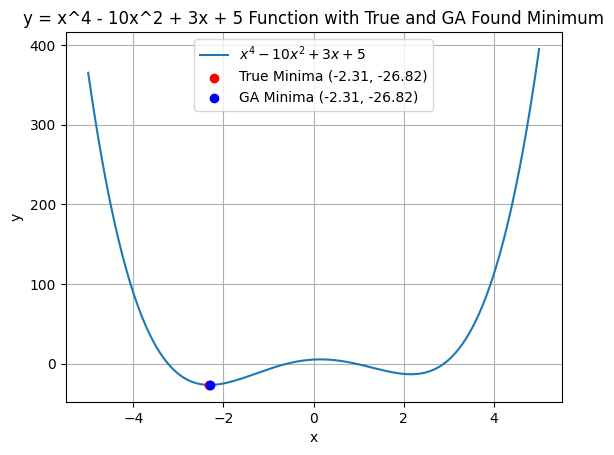

In [21]:
# Display the true and GA-evaluated minima before the plot
print(f"True Minima: ({true_min_x:.2f}, {true_min_y:.2f})")
print(f"GA Minima: ({best_individual[0]:.2f}, {best_fitness[0]:.2f})")

# Plot the function again
plt.plot(x_vals, y_vals, label=r"$x^4 - 10x^2 + 3x + 5$")

# Plot true minimum
plt.scatter(true_min_x, true_min_y, color='red', label=f"True Minima ({true_min_x:.2f}, {true_min_y:.2f})", zorder=5)

# Plot GA result
ga_min_x = best_individual[0]
ga_min_y = best_fitness[0]
plt.scatter(ga_min_x, ga_min_y, color='blue', label=f"GA Minima ({ga_min_x:.2f}, {ga_min_y:.2f})", zorder=5)

plt.title("y = x^4 - 10x^2 + 3x + 5 Function with True and GA Found Minimum")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


# Now, minimize the following functions using GA (Home Assignment)

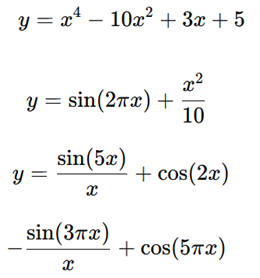